# 15-Enterprise Secrets Security & Hardening Boundaries

In the preceding 14 modules, we constructed an elite, high-throughput, observable MLOps platform. We orchestrated Docker networks, optimized GPU serving engines, and implemented Prometheus metrology.

However, all of this engineering is rendered instantly useless by a single, catastrophic human error: **Hardcoding Secrets**. If a Data Scientist hardcodes an AWS Access Key, a PostgreSQL password, or an OpenAI API token into a Python script and pushes it to a Git repository or bakes it into a Docker image, malicious bots will scrape it within milliseconds. An attacker can spin up thousands of crypto-mining GPU instances on your cloud account, costing hundreds of thousands of dollars before you even wake up.

To engineer absolute enterprise security, we must treat sensitive credentials as **ephemeral, runtime-injected variables** that exist strictly in isolated process memory, completely decoupled from static source code and file systems.

# 1. The Mathematics of Process Memory & Cryptographic Leakage

### Process Memory Isolation ($V_{mem}$)

When the Linux kernel spawns a process $P_i$, it allocates a strictly isolated Virtual Memory space $V_{mem}(P_i)$.
The optimal security architecture injects a secret $S$ directly into this volatile memory space at runtime via an Environment Variable Vector $\mathbf{E}$:


$$S \in \mathbf{E}(P_i)$$


When the process terminates (e.g., the container is shut down), $V_{mem}(P_i)$ is mathematically destroyed by the kernel. The secret ceases to exist. It is never written to the physical hard drive.

### The Docker Layer History Attack

A common catastrophic mistake is passing secrets into a `Dockerfile` during the build phase using `ENV` or `ARG` commands:

```dockerfile
ENV AWS_SECRET_ACCESS_KEY="abC123..." # FATAL ERROR

```

Recall the Immutable Layer Physics from Lesson 08. The Docker daemon hashes the instruction string directly into the read-only file system layer $L_k$.
Even if you attempt to delete the key in a subsequent layer $L_{k+1}$, the data remains mathematically permanently embedded in the cryptographic history of $L_k$.   Anyone who pulls your compiled image can run a simple terminal command: 

$$\text{Attack Vector: } `docker history \text{--no-trunc} \ <image\_id>`$$


This will print the exact plain-text string of your AWS secret to the hacker's terminal.

### The Security Boundary Constraint

To prevent leakage, we enforce a strict boundary constraint:


$$\text{Source Code Repo} \cap \text{Secrets Set} = \emptyset$$


Secrets must be stored locally in `.env` files that are strictly excluded from version control via `.gitignore` and excluded from Docker contexts via `.dockerignore`.

# 2. Imperative Execution: The Local Ephemeral Injection

Let's use Python to programmatically establish our secure environment boundaries. We will generate a mock `.env` file, secure it using absolute POSIX permissions (Lesson 01), and dynamically load it into process memory.

In [1]:
import os
import subprocess

print("--- 🚀 Initializing Secrets Security Lab ---")

sec_sandbox = "./security_sandbox"
os.makedirs(sec_sandbox, exist_ok=True)

# 1. 📝 Establish the .env File (The Local Vault)
env_path = os.path.join(sec_sandbox, ".env")
with open(env_path, "w") as f:
    f.write("DB_PASSWORD=SuperSecretDatabaseToken2026!\n")
    f.write("LLM_API_KEY=llm-key-xyz789\n")

# 🔒 ENFORCE POSIX BOUNDARY: Owner read/write ONLY. (Octal 600)
os.chmod(env_path, 0o600)
print(f"   ✅ Local .env file generated and mathematically hardened (chmod 600): {env_path}")

# 2. 🛡️ Establish the .gitignore & .dockerignore boundaries
gitignore_path = os.path.join(sec_sandbox, ".gitignore")
dockerignore_path = os.path.join(sec_sandbox, ".dockerignore")

with open(gitignore_path, "w") as f: f.write(".env\n")
with open(dockerignore_path, "w") as f: f.write(".env\n")

print(f"   ✅ .gitignore and .dockerignore compiled. The vault is shielded from git and docker payloads.")

# 3. ⚡ Simulating Secure Runtime Injection
print("\n--- ⚡ Executing Secure Runtime Extraction ---")
# Create a dummy Python script that requires the secret
app_code = """
import os
# The code relies on the OS kernel environment matrix, NOT a hardcoded string
db_pass = os.environ.get("DB_PASSWORD")
if not db_pass:
    print("❌ CRITICAL FATAL: DB_PASSWORD not found in kernel environment. Halting execution.")
    exit(1)
else:
    print("✅ SUCCESS: Database connected securely via volatile memory injection.")
"""
app_path = os.path.join(sec_sandbox, "secure_app.py")
with open(app_path, "w") as f: f.write(app_code)

# Execute the script, injecting the .env variables natively via the shell process vector
cmd_run = f"set -a && source {env_path} && set +a && python {app_path}"
res = subprocess.run(cmd_run, shell=True, executable='/bin/bash', capture_output=True, text=True)
print(res.stdout.strip())

--- 🚀 Initializing Secrets Security Lab ---
   ✅ Local .env file generated and mathematically hardened (chmod 600): ./security_sandbox/.env
   ✅ .gitignore and .dockerignore compiled. The vault is shielded from git and docker payloads.

--- ⚡ Executing Secure Runtime Extraction ---
✅ SUCCESS: Database connected securely via volatile memory injection.


# 3. Declarative Execution: The Docker Compose Secrets Matrix

In production, we map secrets into our isolated microservice grid using Docker Compose. Instead of hardcoding keys in our `docker-compose.yml` (which gets committed to Git), we pass the isolated `.env` file directly into the container's runtime layer.

In [2]:
import yaml

print("\n--- ⚡ Compiling Declarative Container Security Matrix ---")

# 📝 Define the Docker Compose Blueprint mapping the external .env file
secure_compose_blueprint = {
    "version": "3.8",
    "services": {
        "secure-inference-api": {
            "image": "python:3.10-slim",
            "container_name": "hardened_api_node",
            # The environment variables are dynamically pulled from the host at runtime
            # They NEVER touch the immutable image layers
            "env_file": [
                ".env" 
            ],
            "command": "python -c 'import os; print(\"Container Booted. API Key Loaded: \" + os.environ.get(\"LLM_API_KEY\", \"FAIL\"))'"
        }
    }
}

compose_path = os.path.join(sec_sandbox, "docker-compose.yml")
with open(compose_path, "w") as f:
    yaml.dump(secure_compose_blueprint, f, default_flow_style=False)

print(f"   ✅ Secure Docker Compose Blueprint Compiled: {compose_path}")
print("   -> Physics: When 'docker compose up' executes, the daemon reads the local .env file on the host machine.")
print("   -> It injects those strings directly into the container's isolated RAM.")
print("   -> If the container crashes or is deleted, the secrets vanish instantly from the node.")


--- ⚡ Compiling Declarative Container Security Matrix ---
   ✅ Secure Docker Compose Blueprint Compiled: ./security_sandbox/docker-compose.yml
   -> Physics: When 'docker compose up' executes, the daemon reads the local .env file on the host machine.
   -> It injects those strings directly into the container's isolated RAM.
   -> If the container crashes or is deleted, the secrets vanish instantly from the node.


# 4. Visualizing Secrets Leakage vs. Runtime Injection

To understand the mathematical persistence of data in containerization, let's graph the physics of the Docker Layer Attack Vector against our Secure Runtime Injection Architecture.

/tmp/ipykernel_6885/3213160724.py:15: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 0.5), 6.0, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_6885/3213160724.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 4.5), 5.0, 2.0, fill=True, color='#e74c3c', alpha=0.2, edgecolor='black', linewidth=2))
/tmp/ipykernel_6885/3213160724.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.5, 5.3), 4.0, 0.6, fill=True, color='#c0392b', edgecolor='black'))
/tmp/ipykernel_6885/3213160724.py:25: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.5, 4.7), 4.0, 0.6, fill=True, color='#bdc3c7', edgecolor=

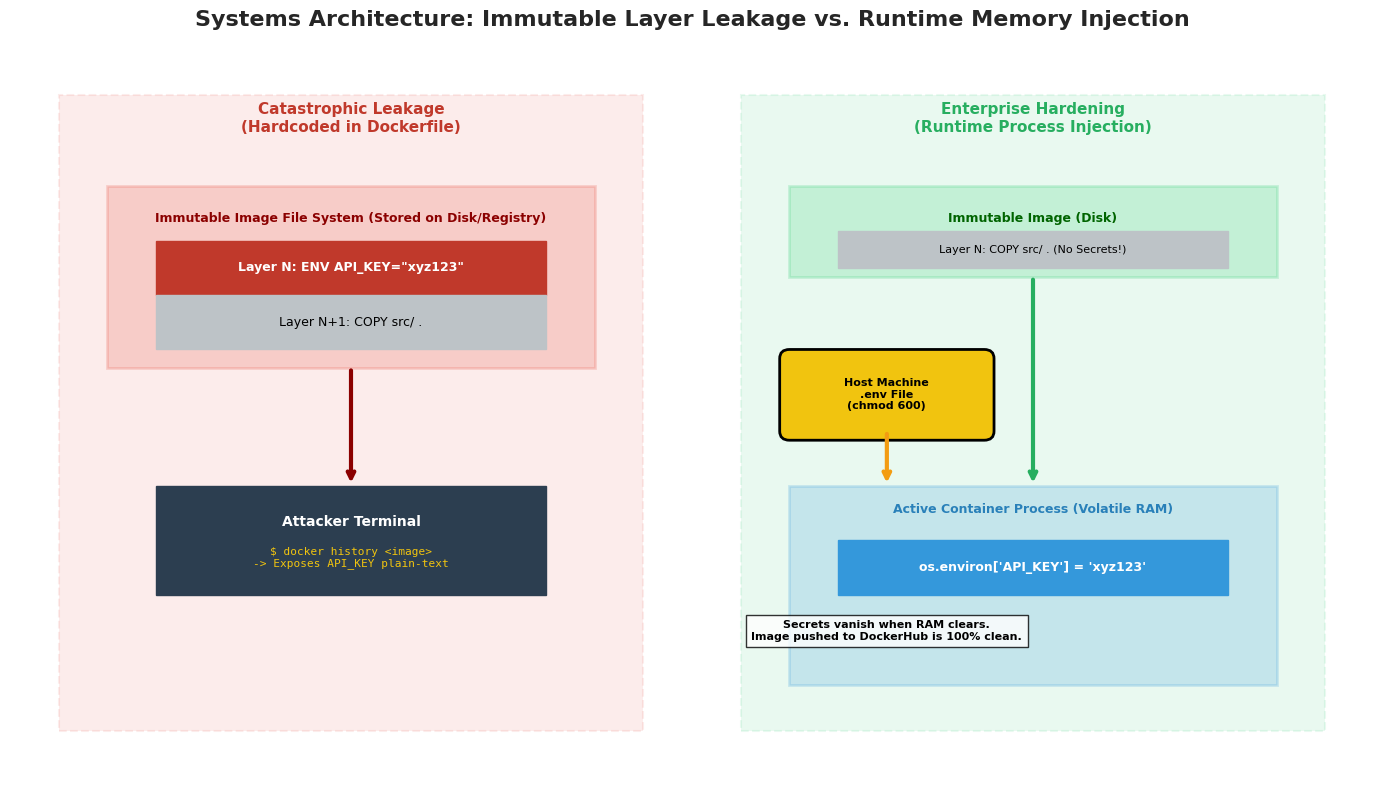

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create structural canvas layout
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: Immutable Layer Leakage vs. Runtime Memory Injection", fontsize=16, fontweight='bold')
ax.axis('off')

# ----------------------------------------------------
# LEFT: THE CATASTROPHIC LEAK (Hardcoded ENV Layer)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((0.5, 0.5), 6.0, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(3.5, 7.1, "Catastrophic Leakage\n(Hardcoded in Dockerfile)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

# Immutable Image Layers
ax.add_patch(patches.Rectangle((1.0, 4.5), 5.0, 2.0, fill=True, color='#e74c3c', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(3.5, 6.1, "Immutable Image File System (Stored on Disk/Registry)", ha='center', color='darkred', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((1.5, 5.3), 4.0, 0.6, fill=True, color='#c0392b', edgecolor='black'))
ax.text(3.5, 5.6, "Layer N: ENV API_KEY=\"xyz123\"", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((1.5, 4.7), 4.0, 0.6, fill=True, color='#bdc3c7', edgecolor='black'))
ax.text(3.5, 5.0, "Layer N+1: COPY src/ .", ha='center', va='center', color='black', fontsize=9)

# Attacker extraction
ax.add_patch(patches.Rectangle((1.5, 2.0), 4.0, 1.2, fill=True, color='#2c3e50', edgecolor='black'))
ax.text(3.5, 2.8, "Attacker Terminal", ha='center', va='center', color='white', fontweight='bold', fontsize=10)
ax.text(3.5, 2.4, "$ docker history <image>\n-> Exposes API_KEY plain-text", ha='center', va='center', color='#f1c40f', fontfamily='monospace', fontsize=8)

ax.annotate("", xy=(3.5, 3.2), xytext=(3.5, 4.5), arrowprops=dict(arrowstyle="->", lw=3, color="darkred"))


# ----------------------------------------------------
# RIGHT: ENTERPRISE SECURITY (Volatile RAM Injection)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((7.5, 0.5), 6.0, 7.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10.5, 7.1, "Enterprise Hardening\n(Runtime Process Injection)", ha='center', color='#27ae60', fontweight='bold', fontsize=11)

# Clean Immutable Image Layers
ax.add_patch(patches.Rectangle((8.0, 5.5), 5.0, 1.0, fill=True, color='#2ecc71', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(10.5, 6.1, "Immutable Image (Disk)", ha='center', color='darkgreen', fontweight='bold', fontsize=9)
ax.add_patch(patches.Rectangle((8.5, 5.6), 4.0, 0.4, fill=True, color='#bdc3c7', edgecolor='black'))
ax.text(10.5, 5.8, "Layer N: COPY src/ . (No Secrets!)", ha='center', va='center', color='black', fontsize=8)

# The Local Host Vault
ax.add_patch(patches.FancyBboxPatch((8.0, 3.8), 2.0, 0.8, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f1c40f'))
ax.text(9.0, 4.2, "Host Machine\n.env File\n(chmod 600)", ha='center', va='center', color='black', fontweight='bold', fontsize=8)

# Running Container Process Space
ax.add_patch(patches.Rectangle((8.0, 1.0), 5.0, 2.2, fill=True, color='#3498db', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(10.5, 2.9, "Active Container Process (Volatile RAM)", ha='center', color='#2980b9', fontweight='bold', fontsize=9)

ax.add_patch(patches.Rectangle((8.5, 2.0), 4.0, 0.6, fill=True, color='#3498db', edgecolor='black'))
ax.text(10.5, 2.3, "os.environ['API_KEY'] = 'xyz123'", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Injection Vectors
ax.annotate("", xy=(9.0, 3.2), xytext=(9.0, 3.8), arrowprops=dict(arrowstyle="->", lw=3, color="#f39c12"))
ax.annotate("", xy=(10.5, 3.2), xytext=(10.5, 5.5), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))

ax.text(9.0, 1.5, "Secrets vanish when RAM clears.\nImage pushed to DockerHub is 100% clean.", ha='center', color='black', fontweight='bold', fontsize=8, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.xlim(0, 14.0)
plt.ylim(0, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Enterprise Secrets Management like **The Hotel Keycard vs. The Forehead Tattoo**:

* **Hardcoding Secrets / Docker ENV Variables (The Forehead Tattoo):** You check into a hotel. The receptionist asks for your room keycode. Instead of giving you a card, they permanently tattoo your room number and the master safe passcode directly onto your forehead. You go out for dinner, and everyone in the restaurant can read your passcode. Even if you leave the hotel (delete the code from the latest file), the tattoo is permanently visible in your medical history (Docker Layer History). Your security is mathematically compromised forever.
* **Runtime Environment Variables (The Temporary NFC Keycard):** You check into a secure corporate facility. The receptionist verifies your identity and programs a blank, plastic NFC Keycard (The `.env` variable).
* The card contains a temporary magnetic signature (Volatile RAM).
* You use the card to open doors while you are actively working inside the building (Process Execution).
* The exact second you clock out and leave the building (Container Shutdown), the security system remotely scrambles the magnetic signature on the card. The card becomes a useless piece of plastic. Even if an attacker steals the plastic card from the trash, it holds absolutely zero historical data.



By treating system credentials as ephemeral strings injected strictly into kernel-level memory boundaries, MLOps engineers ensure that even if their Git repository becomes completely public, their enterprise infrastructure remains impenetrable.